# Phishing Cross-Dataset Feature Robustness Study — Training & Evaluation  
**Project Goal**: Investigate model performance and feature robustness across diverse phishing datasets.  
  **Models:**
     1. **Logistic Regression:** Baseline linear classifier  
     2. **Random Forest:** Tree-based ensemble (robust to mixed features)  
     3. **FT-Transformer:** Deep Learning Transformer for Tabular Data  
       
  **Protocols:**  
     1. **Within-Dataset:** Train/Test on same dataset (80/20 split) to establish baseline  
     2. **Cross-Dataset:** Train on Dataset X  Test on Dataset Y to assess generalization  
     3. **Merged Datasets:** Train on X+Y  Test on Z to see if data diversity improves performance.

# Step 1: Set up

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics & classical model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report, precision_score, recall_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
from scipy import stats
import shap

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Weights & Biases
import wandb

In [2]:
# Configuration
pd.set_option('display.max_columns', None)
RANDOM_SEED = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Set this to True to enable logging
USE_WANDB = True
WANDB_PROJECT = 'phishing-feature-robustness'
print(f"Using device: {device}")
if USE_WANDB:
  wandb.login()

Using device: cpu


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: minhnhatgd0808 (minhnhatgd0808-university-of-houston) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# step 2: define model

In [3]:
from sklearn.preprocessing import StandardScaler

class SimpleFTTransformer(nn.Module):
  def __init__(self, num_numerical_features, embed_dim=32, num_heads=4, num_layers=3, dropout=0.1):
    super().__init__()
    # Feature Tokenizer: Treat numerical features as individual 'tokens' via linear projection
    self.feature_tokenizer = nn.ModuleList([
        nn.Linear(1, embed_dim) for _ in range(num_numerical_features)
    ])
    # CLS Token (learnable embedding for classification)
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    # Transformer Encoder
    encoder_layer = nn.TransformerEncoderLayer(
        d_model=embed_dim,
        nhead=num_heads,
        dim_feedforward=embed_dim*2,
        dropout=dropout,
        batch_first=True
    )
    self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    # Classification Head
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Linear(embed_dim, 1) # Binary output (logits)
    )

  def forward(self, x_numerical):
    batch_size = x_numerical.shape[0]

    # Tokenize: (Batch, Num_Features) -> (Batch, Num_Features, Embed_Dim)
    x_numerical = x_numerical.unsqueeze(-1)
    tokens = [layer(x_numerical[:, i]) for i, layer in enumerate(self.feature_tokenizer)]
    x = torch.stack(tokens, dim=1)

    # Prepend CLS token
    cls_tokens = self.cls_token.expand(batch_size, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)

    # Apply Transformer
    x = self.transformer(x)

    # Use CLS token output (index 0) for prediction
    cls_output = x[:, 0, :]
    return self.mlp_head(cls_output)

class TabularTransformerClassifier(BaseEstimator, ClassifierMixin):
    """Sklearn wrapper for the PyTorch FT-Transformer"""
    def __init__(self, epochs=20, batch_size=64, learning_rate=1e-3, use_wandb=False, patience=5, min_delta=0.001):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.use_wandb = use_wandb
        self.patience = patience
        self.min_delta = min_delta
        self.model = None
        self.scaler = StandardScaler()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def fit(self, X, y):
        # Scale features internally (important for neural nets)
        X_scaled = self.scaler.fit_transform(X)

        # Convert to Tensor
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(self.device)
        y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1).to(self.device)

        # Initialize Model
        num_features = X.shape[1]
        self.model = SimpleFTTransformer(num_features).to(self.device)
        optimizer = optim.AdamW(self.model.parameters(), lr=self.learning_rate)
        criterion = nn.BCEWithLogitsLoss()

        # Training Loop
        self.model.train()
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        print(f"Training FT-Transformer for {self.epochs} epochs...")
        best_loss = float('inf')
        patience_counter = 0

        for epoch in range(self.epochs):
            epoch_loss = 0
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            avg_loss = epoch_loss / len(loader)
            if self.use_wandb:
                wandb.log({'train_loss': avg_loss, 'epoch': epoch})

            # Early Stopping Check
            if avg_loss < best_loss - self.min_delta:
                best_loss = avg_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print(f"Early stopping triggered at epoch {epoch} (Loss: {avg_loss:.4f})")
                    break

        return self

    def predict_proba(self, X):
        self.model.eval()
        X_scaled = self.scaler.transform(X)
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()
        # Return (N, 2) array [Prob_0, Prob_1]
        return np.hstack([1 - probs, probs])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs > 0.5).astype(int)

# Step 3: Load data

In [4]:
DATA_DIR = './cleaned'
datasets_common = {}
datasets_full = {}
try:
    # Load Common Features (Dataset A, B, C)
    datasets_common['A'] = pd.read_csv(os.path.join(DATA_DIR, 'A_common.csv'))
    datasets_common['B'] = pd.read_csv(os.path.join(DATA_DIR, 'B_common.csv'))
    datasets_common['C'] = pd.read_csv(os.path.join(DATA_DIR, 'C_common.csv'))

    # Load Full Features (Dataset A, B, C)\n",
    datasets_full['A'] = pd.read_csv(os.path.join(DATA_DIR, 'A_full.csv'))
    datasets_full['B'] = pd.read_csv(os.path.join(DATA_DIR, 'B_full.csv'))
    datasets_full['C'] = pd.read_csv(os.path.join(DATA_DIR, 'C_full.csv'))

    """
    df_A = pd.read_csv(os.path.join(DATA_DIR, 'A_common.csv'))
    df_B = pd.read_csv(os.path.join(DATA_DIR, 'B_common.csv'))
    df_C = pd.read_csv(os.path.join(DATA_DIR, 'C_common.csv'))

    datasets = {
        'A': df_A,
        'B': df_B,
        'C': df_C,
    }"""
    print("Datasets loaded successfully")
    print(f"Common Features: {len(datasets_common['A'].columns)-1} features")
    print(f"Full Features A: {len(datasets_full['A'].columns)-1} features")
    print(f"Full Features B: {len(datasets_full['B'].columns)-1} features")
    print(f"Full Features C: {len(datasets_full['C'].columns)-1} features")
except FileNotFoundError:
    print('Error: Dataset files not found. Please run the Preprocessing Notebook first.')

Datasets loaded successfully
Common Features: 23 features
Full Features A: 48 features
Full Features B: 92 features
Full Features C: 75 features


# Step 4: Define evaluation functions

In [5]:
def evaluate_model(model, X_test, y_test, model_name, train_set_name, test_set_name, experiment_type):
        """Calculates Accuracy, F1, ROC-AUC, PR-AUC, Precision, and Recall."""
        y_pred = model.predict(X_test)

        # Handle probabilities for AUC
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = y_pred # Fallback if no proba

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        return {
            'Model': model_name,
            'Train_Set': train_set_name,
            'Test_Set': test_set_name,
            'Type': experiment_type,
            'Accuracy': acc,
            'F1_Score': f1,
            'ROC_AUC': roc,
            'PR_AUC': pr_auc,
            'Precision': precision,
            'Recall': recall,
        }

def get_X_y(df):
        X = df.drop(columns=['label'])
        y = df['label']
        return X, y

# Global Results Log
results_log = []

## Step 5. Protocol 1: Within-Dataset Baseline,
    Train on 80%, Test on 20% of the same dataset.

In [6]:
MODELS_CONFIG = {
    "LogisticRegression": lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    "RandomForest": lambda: RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "FT-Transformer": lambda: TabularTransformerClassifier(epochs=15, batch_size=64, learning_rate=1e-3)
}

# Store trained common-feature models for Section 9 analysis
trained_baselines_common = {}

# Store baseline AUCs for gap calculation
baseline_results_common = {}

print("--- Protocol 1A: Within-Dataset (FULL FEATURES) ---")
for name, df in datasets_full.items():
    print(f"Processing Full Dataset {name}...")
    X, y = get_X_y(df)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

    for model_name, model_factory in MODELS_CONFIG.items():
        if USE_WANDB:
            wandb.init(
                project=WANDB_PROJECT,
                group="Protocol_1A_Full",
                name=f"{model_name}_Full_{name}",
                config={"model": model_name, "dataset": name, "features": "full"},
                reinit=True
            )

        clf = model_factory()
        clf.fit(X_train, y_train)
        metrics = evaluate_model(clf, X_test, y_test, model_name, name, name, "Baseline (Full)")
        results_log.append(metrics)
        print(f"   [{model_name}] Full AUC: {metrics['ROC_AUC']:.4f}")

        if USE_WANDB: wandb.finish()

print("\n--- Protocol 1B: Within-Dataset (COMMON FEATURES) ---")
for name, df in datasets_common.items():
    print(f"Processing Common Dataset {name}...")
    X, y = get_X_y(df)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

    trained_baselines_common[name] = {}

    for model_name, model_factory in MODELS_CONFIG.items():
        if USE_WANDB:
            wandb.init(
                project=WANDB_PROJECT,
                group="Protocol_1B_Common",
                name=f"{model_name}_Common_{name}",
                config={"model": model_name, "dataset": name, "features": "common"},
                reinit=True
            )

        clf = model_factory()
        clf.fit(X_train, y_train)
        metrics = evaluate_model(clf, X_test, y_test, model_name, name, name, "Baseline (Common)")
        results_log.append(metrics)

        # Store for Gap Calculation & Feature Importance
        baseline_results_common[(model_name, name)] = metrics['ROC_AUC']
        trained_baselines_common[name][model_name] = clf

        print(f"   [{model_name}] Common AUC: {metrics['ROC_AUC']:.4f}")

        if USE_WANDB: wandb.finish()

--- Protocol 1A: Within-Dataset (FULL FEATURES) ---
Processing Full Dataset A...


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


   [LogisticRegression] Full AUC: 0.9868


   [RandomForest] Full AUC: 0.9989


Training FT-Transformer for 15 epochs...
   [FT-Transformer] Full AUC: 0.9968


...

Training FT-Transformer for 15 epochs...
   [FT-Transformer] Common AUC: 0.9376


Processing Common Dataset C...


   [LogisticRegression] Common AUC: 0.9338


   [RandomForest] Common AUC: 0.9875


Training FT-Transformer for 15 epochs...
   [FT-Transformer] Common AUC: 0.9781


## Step 6: Protocol 2: Cross-Dataset Generalization,
    Train on Dataset Source (100%), Test on Dataset Target (100%).

In [7]:
print("\n--- Protocol 2: Cross-Dataset Generalization ---")

dataset_names = list(datasets_common.keys())

for source in dataset_names:
    for target in dataset_names:
        if source == target:
            continue

        print(f"Train {source} -> Test {target}")

        X_train, y_train = get_X_y(datasets_common[source])
        X_test, y_test = get_X_y(datasets_common[target])

        for model_name, model_factory in MODELS_CONFIG.items():
            if USE_WANDB:
                wandb.init(
                    project=WANDB_PROJECT,
                    group="Protocol_2_Cross",
                    name=f"{model_name}_{source}_to_{target}",
                    config={"model": model_name, "train_set": source, "test_set": target, "protocol": 2},
                    reinit=True
                )

            clf = model_factory()
            clf.fit(X_train, y_train)

            metrics = evaluate_model(clf, X_test, y_test, model_name, source, target, "Cross-Dataset")
            results_log.append(metrics)
            print(f"   [{model_name}] AUC: {metrics['ROC_AUC']:.4f}")

            if USE_WANDB:
                wandb.finish()


--- Protocol 2: Cross-Dataset Generalization ---
Train A -> Test B


   [LogisticRegression] AUC: 0.7553


   [RandomForest] AUC: 0.6957


Training FT-Transformer for 15 epochs...
   [FT-Transformer] AUC: 0.7462


Train A -> Test C


...

Training FT-Transformer for 15 epochs...
   [FT-Transformer] AUC: 0.9052


Train C -> Test B


   [LogisticRegression] AUC: 0.7319


   [RandomForest] AUC: 0.7433


Training FT-Transformer for 15 epochs...
   [FT-Transformer] AUC: 0.7963


## Step 7: Protocol 3: Merged Datasets,
    Train on A+B, Test on C (and other permutations).

In [8]:
print("\n--- Protocol 3: Merged Datasets ---")

combinations = [
    (['A', 'B'], 'C'),
    (['A', 'C'], 'B'),
    (['B', 'C'], 'A')
]

for train_list, test_name in combinations:
    train_name = "+".join(train_list)
    print(f"Train {train_name} -> Test {test_name}")

    # Merge Train Data
    df_train = pd.concat([datasets_common[d] for d in train_list], ignore_index=True)
    df_test = datasets_common[test_name]

    X_train, y_train = get_X_y(df_train)
    X_test, y_test = get_X_y(df_test)

    for model_name, model_factory in MODELS_CONFIG.items():
        if USE_WANDB:
            wandb.init(
                project=WANDB_PROJECT,
                group="Protocol_3_Merged",
                name=f"{model_name}_Merged_{train_name}",
                config={"model": model_name, "train_set": train_name, "test_set": test_name, "protocol": 3},
                reinit=True
            )

        clf = model_factory()
        clf.fit(X_train, y_train)

        metrics = evaluate_model(clf, X_test, y_test, model_name, train_name, test_name, "Merged")
        results_log.append(metrics)
        print(f"   [{model_name}] AUC: {metrics['ROC_AUC']:.4f}")

        if USE_WANDB:
            wandb.finish()


--- Protocol 3: Merged Datasets ---
Train A+B -> Test C


   [LogisticRegression] AUC: 0.8316


   [RandomForest] AUC: 0.8756


Training FT-Transformer for 15 epochs...
   [FT-Transformer] AUC: 0.8858


Train A+C -> Test B


...

Training FT-Transformer for 15 epochs...
   [FT-Transformer] AUC: 0.7817


Train B+C -> Test A


   [LogisticRegression] AUC: 0.8336


   [RandomForest] AUC: 0.8316


Training FT-Transformer for 15 epochs...
   [FT-Transformer] AUC: 0.8949


## Step 8: Analysis & Gap Calculation

> Calculate: $\\Delta AUC = AUC_{indataset} - AUC_{crossdataset}$


    

In [9]:
results_df = pd.DataFrame(results_log)

def calculate_gap(row):
    # Only applicable for Cross-Dataset rows
    if row['Type'] == 'Cross-Dataset':
        # Compare against the COMMON baseline for fair comparison
        base_auc = baseline_results_common.get((row['Model'], row['Train_Set']), np.nan)
        return base_auc - row['ROC_AUC']
    return 0.0

results_df['Gen_Gap_AUC'] = results_df.apply(calculate_gap, axis=1)

# Display Top Results
print("\nSample Results:")
display(results_df.head(10))

# Save Results
output_path = os.path.join(DATA_DIR, 'experiment_results_log.csv')
results_df.to_csv(output_path, index=False)
print(f"\nFull results saved to {output_path}")


Sample Results:


,Model,Train_Set,Test_Set,Type,Accuracy,F1_Score,ROC_AUC,PR_AUC,Precision,Recall,Gen_Gap_AUC
0,LogisticRegression,A,A,Baseline (Full),0.952000,0.952381,0.986837,0.986362,0.944882,0.960000,0.0
1,RandomForest,A,A,Baseline (Full),0.985500,0.985493,0.998927,0.999000,0.985986,0.985000,0.0
2,FT-Transformer,A,A,Baseline (Full),0.975500,0.975682,0.996780,0.997094,0.968473,0.983000,0.0
3,LogisticRegression,B,B,Baseline (Full),0.936570,0.936487,0.981561,0.980885,0.937719,0.935258,0.0
4,RandomForest,B,B,Baseline (Full),0.960192,0.960314,0.993050,0.992670,0.957391,0.963255,0.0
5,FT-Transformer,B,B,Baseline (Full),0.956255,0.956025,0.989328,0.988352,0.961096,0.951006,0.0
6,LogisticRegression,C,C,Baseline (Full),0.924166,0.899358,0.973808,0.960023,0.902148,0.896584,0.0
7,RandomForest,C,C,Baseline (Full),0.967372,0.956667,0.994938,0.992494,0.960325,0.953036,0.0
8,FT-Transformer,C,C,Baseline (Full),0.955360,0.941563,0.990787,0.986437,0.931723,0.951613,0.0
9,LogisticRegression,A,A,Baseline (Common),0.863500,0.862607,0.949649,0.949294,0.868288,0.857000,0.0



Full results saved to ./cleaned/experiment_results_log.csv


## Step 9: :Visualization: Model Performance Comparison,
    Comparing ROC-AUC across different models and protocols.

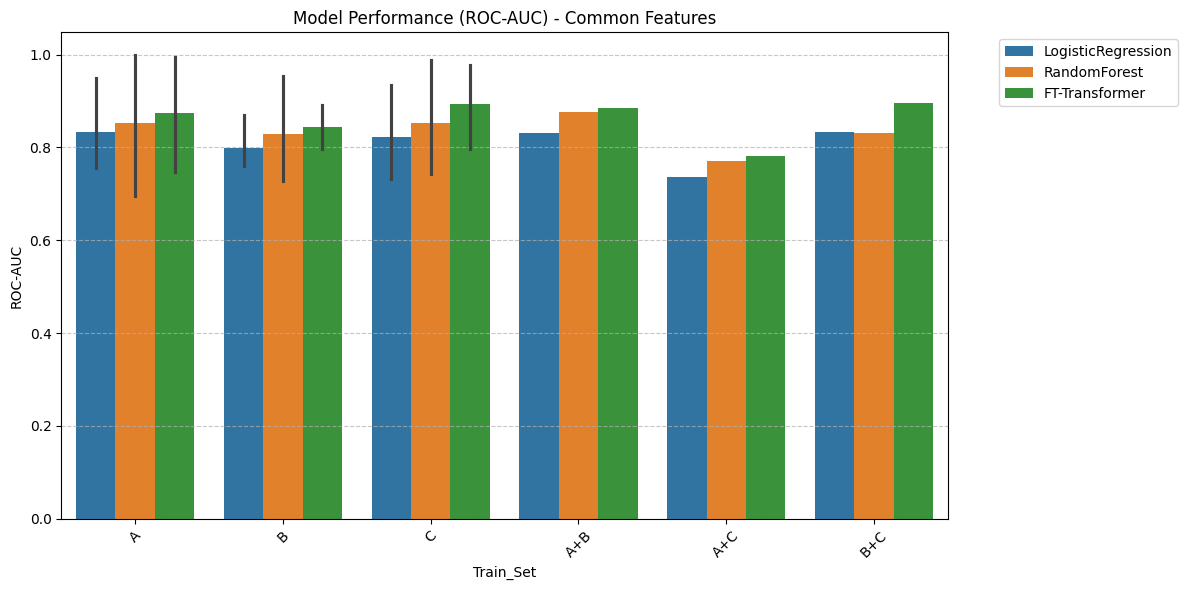

In [10]:
plt.figure(figsize=(12, 6))

# Filter: Exclude 'Baseline (Full)' to compare only Common Feature experiments (Within vs Cross vs Merged)
plot_data = results_df[results_df['Type'] != 'Baseline (Full)']

sns.barplot(data=plot_data, x='Train_Set', y='ROC_AUC', hue='Model')
plt.title('Model Performance (ROC-AUC) - Common Features')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Step 10. Feature Importance & Robustness Analysis
  This section computes:  
    1. **Permutation Importance & SHAP:** For each model trained in Protocol 1  
    2. **Robustness Score (R):**  
    3. **Spearman Rank Correlation:** Between feature importance and SHAP stability

> R = Mean / (1 + Std)  

    

In [12]:
def calculate_robustness(imp_df):
    """Calculates R = Mean / (1 + Std) across datasets for each feature."""
    mean_imp = imp_df.mean(axis=1)
    std_imp = imp_df.std(axis=1)
    robustness_score = mean_imp / (1 + std_imp)
    return mean_imp, std_imp, robustness_score

print("--- Starting Feature Importance Analysis ---")

# FIXED: Use datasets_common instead of datasets
feature_names = list(datasets_common['A'].drop(columns=['label']).columns)

# Storage for importance matrices
all_model_importances = {}

for model_name in MODELS_CONFIG.keys():
    print(f"\nAnalyzing {model_name}...")

    # DataFrame to store importance of each feature for Datasets A, B, C
    model_imp_df = pd.DataFrame(index=feature_names)

    # FIXED: Iterate over datasets_common
    for dataset_name in datasets_common.keys():
        # Instantiate and fit model since trained_baselines wasn't saved
        clf = MODELS_CONFIG[model_name]()
        X_data, y_data = get_X_y(datasets_common[dataset_name])
        clf.fit(X_data, y_data)

        # Use a small subset for SHAP/Permutation speed
        X_sample = X_data.sample(min(500, len(X_data)), random_state=RANDOM_SEED)
        y_sample = y_data.loc[X_sample.index]

        # 1. Permutation Importance (Model Agnostic & Robust)
        perm_results = permutation_importance(clf, X_sample, y_sample, n_repeats=5, random_state=RANDOM_SEED)
        importances = perm_results.importances_mean

        # 2. SHAP (Model Specific)
        try:
            if model_name == 'RandomForest':
                explainer = shap.TreeExplainer(clf)
                shap_values = explainer.shap_values(X_sample)
                if isinstance(shap_values, list):
                    shap_vals = np.abs(shap_values[1]).mean(axis=0)
                else:
                    shap_vals = np.abs(shap_values).mean(axis=0)

            elif model_name == 'LogisticRegression':
                explainer = shap.LinearExplainer(clf, X_sample)
                shap_values = explainer.shap_values(X_sample)
                shap_vals = np.abs(shap_values).mean(axis=0)

        except Exception as e:
            pass

        model_imp_df[dataset_name] = importances

    # Calculate Robustness Score R
    mean_imp, std_imp, r_score = calculate_robustness(model_imp_df)

    model_imp_df['Mean_Imp'] = mean_imp
    model_imp_df['Std_Imp'] = std_imp
    model_imp_df['Robustness_R'] = r_score

    spearman_corr, _ = stats.spearmanr(model_imp_df['Mean_Imp'], model_imp_df['Std_Imp'])
    print(f"   Spearman Corr (Imp vs Std): {spearman_corr:.4f}")

    all_model_importances[model_name] = model_imp_df

    print(f"   Top 5 Robust Features (High R):")
    display(model_imp_df.sort_values(by='Robustness_R', ascending=False).head(5))

--- Starting Feature Importance Analysis ---

Analyzing LogisticRegression...
   Spearman Corr (Imp vs Std): 0.9140
   Top 5 Robust Features (High R):


,A,B,C,Mean_Imp,Std_Imp,Robustness_R
url_length,0.1096,0.0184,0.2292,0.119067,0.105718,0.107683
path_length,0.0396,0.0140,0.3080,0.120533,0.162855,0.103653
ratio_external_links,0.0940,0.0476,0.0192,0.053600,0.037759,0.051650
num_dots,0.0588,0.0580,0.0028,0.039867,0.032103,0.038627
hostname_length,0.0552,0.0492,0.0140,0.039467,0.022258,0.038607



Analyzing RandomForest...
   Spearman Corr (Imp vs Std): 0.9061
   Top 5 Robust Features (High R):


,A,B,C,Mean_Imp,Std_Imp,Robustness_R
ratio_external_links,0.1624,0.1524,0.0828,0.132533,0.043360,0.127026
ratio_null_links,0.0728,0.0000,0.0476,0.040133,0.036970,0.038703
num_numeric_chars,0.0124,0.0788,0.0276,0.039600,0.034789,0.038269
path_length,0.0024,0.0460,0.0640,0.037467,0.031674,0.036316
path_depth,0.0056,0.0772,0.0168,0.033200,0.038514,0.031969



Analyzing FT-Transformer...
Training FT-Transformer for 15 epochs...
Training FT-Transformer for 15 epochs...
Training FT-Transformer for 15 epochs...
   Spearman Corr (Imp vs Std): 0.8984
   Top 5 Robust Features (High R):


,A,B,C,Mean_Imp,Std_Imp,Robustness_R
ratio_external_links,0.1492,0.0664,0.0460,0.087200,0.054654,0.082681
path_length,0.0060,0.0240,0.1236,0.051200,0.063343,0.048150
path_depth,0.0200,0.0940,0.0204,0.044800,0.042609,0.042969
num_numeric_chars,0.0160,0.0624,0.0400,0.039467,0.023205,0.038572
ratio_null_links,0.0720,0.0000,0.0284,0.033467,0.036266,0.032295


### Visualization: SHAP values
    "The plot below shows which features are most important and how they impact model (logistic & RandomForest) prediction "


=== Generating SHAP visualization for RandomForest on Dataset A ===
RF SHAP shape (3D): (200, 23, 2)


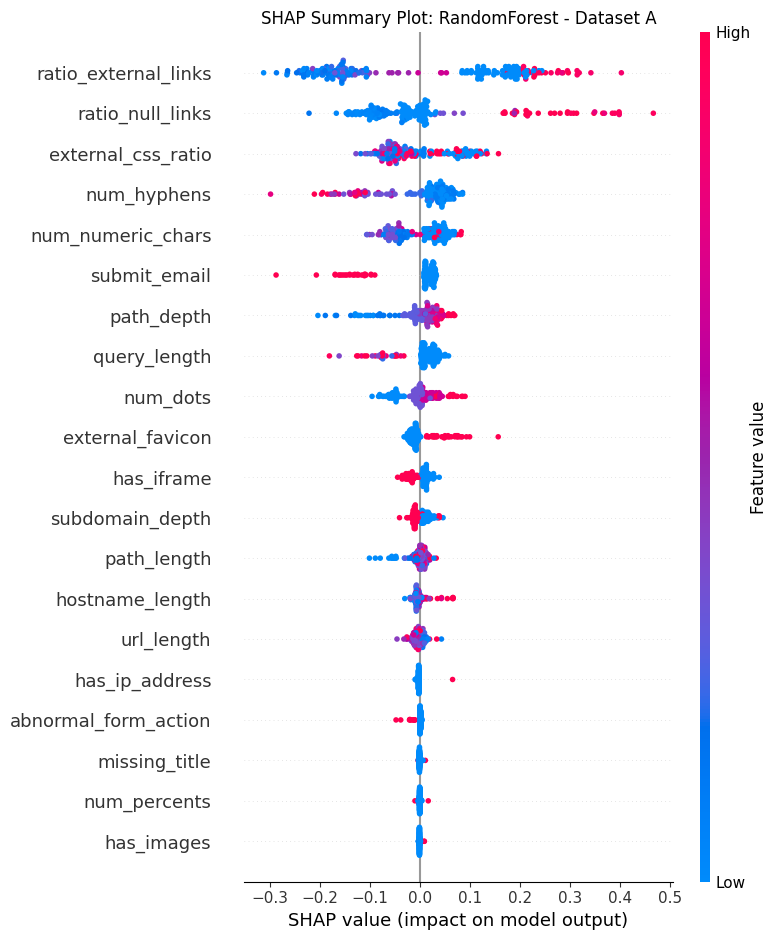


=== Generating SHAP visualization for RandomForest on Dataset B ===
RF SHAP shape (3D): (200, 23, 2)


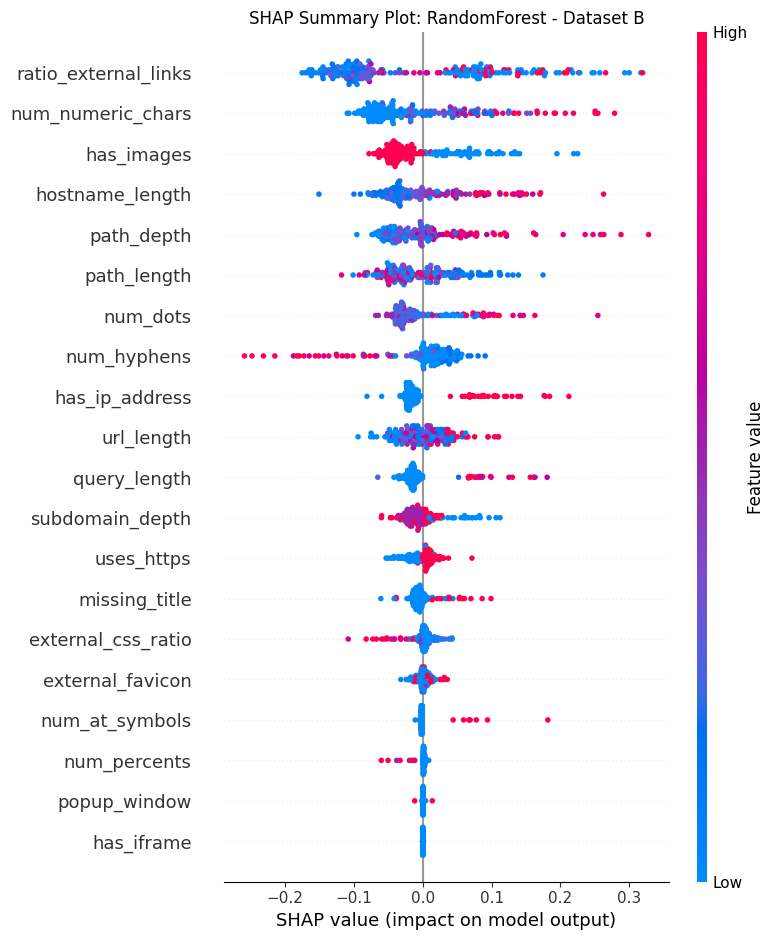


=== Generating SHAP visualization for RandomForest on Dataset C ===
RF SHAP shape (3D): (200, 23, 2)


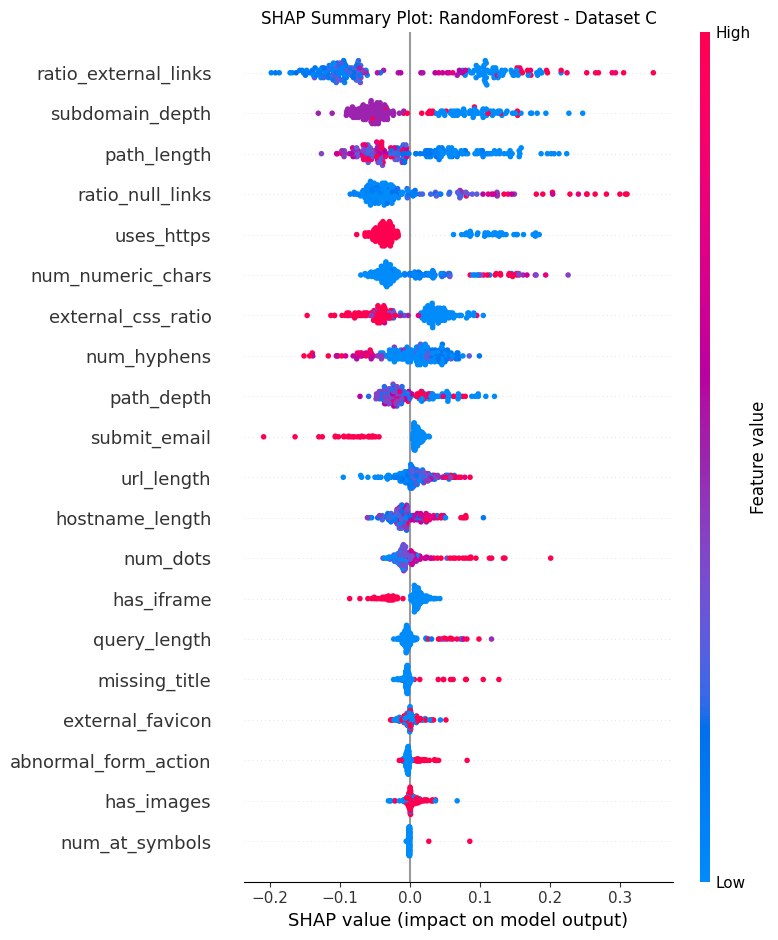


=== Generating SHAP visualization for LogisticRegression on Dataset A ===


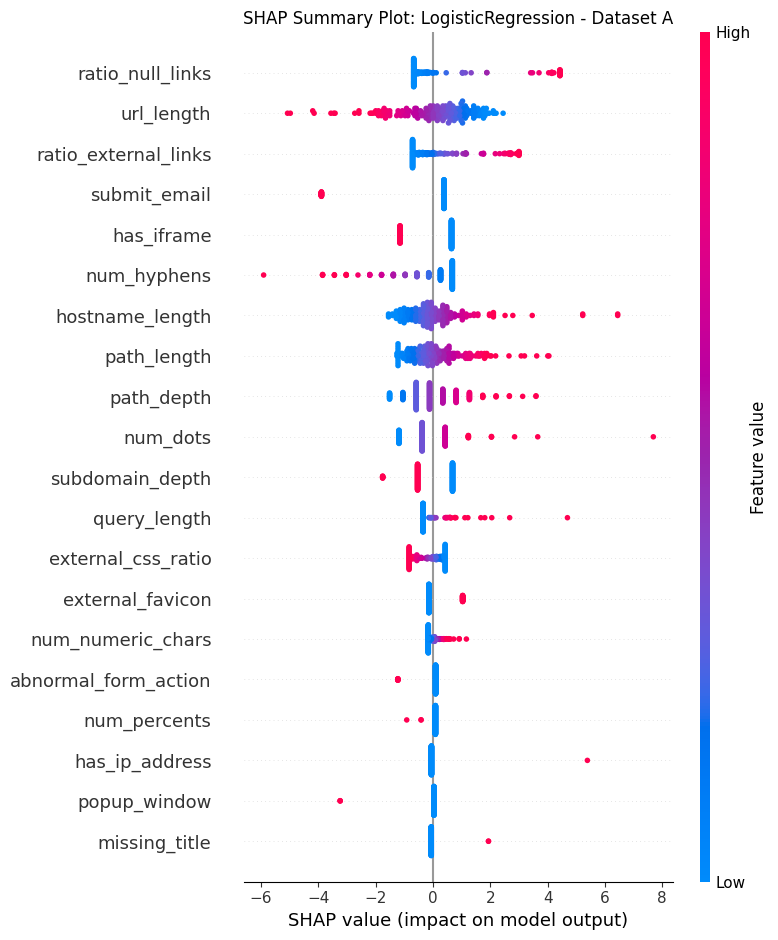


=== Generating SHAP visualization for LogisticRegression on Dataset B ===


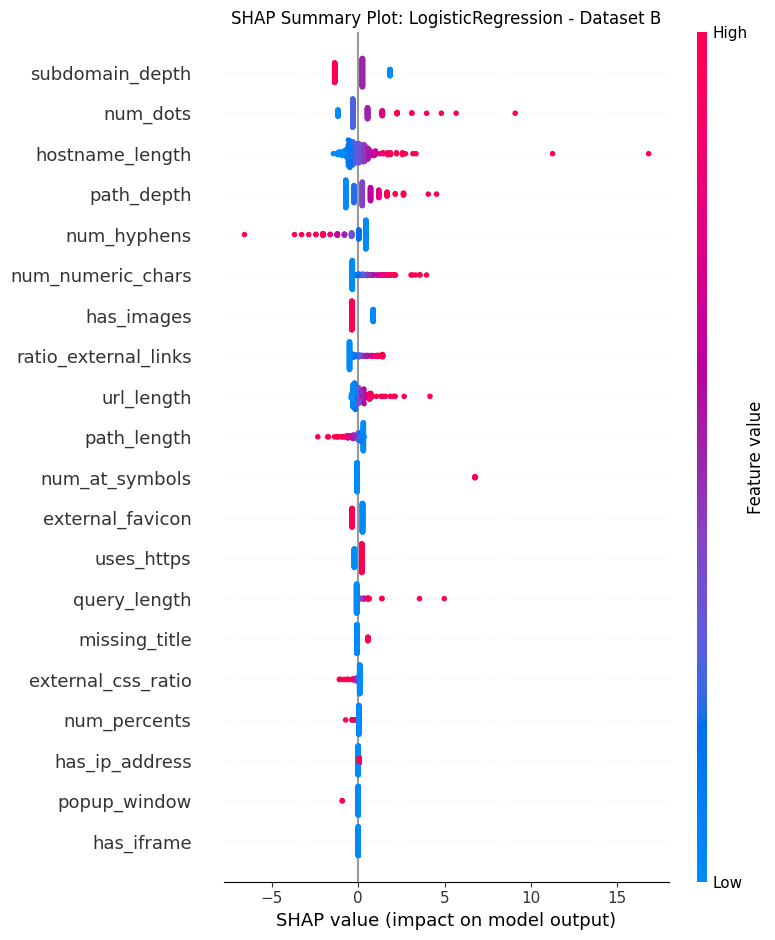


=== Generating SHAP visualization for LogisticRegression on Dataset C ===


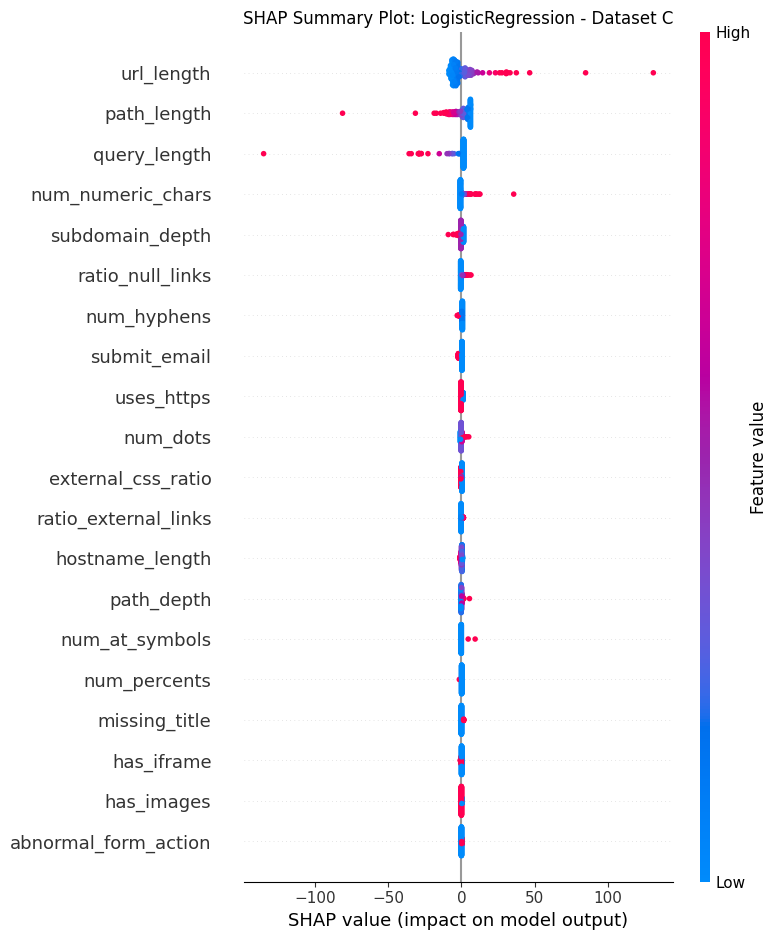

In [16]:
# Configuration for Visualization
supported_shap_models = ['RandomForest', 'LogisticRegression']

for viz_model_name in supported_shap_models:
    for viz_dataset_name in datasets_common.keys():
        print(f"\n=== Generating SHAP visualization for {viz_model_name} on Dataset {viz_dataset_name} ===")

        # 1. Get Data and Train Model
        X, y = get_X_y(datasets_common[viz_dataset_name])
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

        clf = MODELS_CONFIG[viz_model_name]()
        clf.fit(X_train, y_train)

        # 2. Compute SHAP Values
        X_sample = X_test.sample(min(200, len(X_test)), random_state=RANDOM_SEED)
        shap_vals_plot = None

        try:
            if viz_model_name == 'RandomForest':
                explainer = shap.TreeExplainer(clf)
                shap_values = explainer.shap_values(X_sample, check_additivity=False)

                # Robustly handle different return shapes from TreeExplainer
                if isinstance(shap_values, list):
                    # Case: List of arrays [Class0, Class1]
                    print(f"RF SHAP shape (List): len={len(shap_values)}, shape[1]={shap_values[1].shape}")
                    shap_vals_plot = shap_values[1]
                elif len(shap_values.shape) == 3:
                    # Case: 3D Array (Samples, Features, Classes)
                    print(f"RF SHAP shape (3D): {shap_values.shape}")
                    shap_vals_plot = shap_values[:, :, 1]
                else:
                    # Case: 2D Array (Samples, Features) - likely binary implicitly
                    print(f"RF SHAP shape (2D): {shap_values.shape}")
                    shap_vals_plot = shap_values

            elif viz_model_name == 'LogisticRegression':
                masker = shap.maskers.Independent(data=X_train)
                explainer = shap.LinearExplainer(clf, masker=masker)
                shap_values = explainer.shap_values(X_sample)
                shap_vals_plot = shap_values

            # 3. Create Summary Plot
            if shap_vals_plot is not None:
                plt.figure(figsize=(12, 10)) # Increased height
                plt.title(f"SHAP Summary Plot: {viz_model_name} - Dataset {viz_dataset_name}")

                # Explicitly pass feature names to ensure they appear
                shap.summary_plot(shap_vals_plot, X_sample, feature_names=X_sample.columns, show=False)

                plt.tight_layout()
                plt.show()

        except Exception as e:
            print(f"Could not generate SHAP plot for {viz_model_name} on {viz_dataset_name}: {e}")
            import traceback
            traceback.print_exc()

### Visualization: Robustness vs Importance
    "The plot below shows Feature Importance (X) vs. Robustness Score (Y). Features in the top-right are both **highly important** and **highly robust across datasets**."

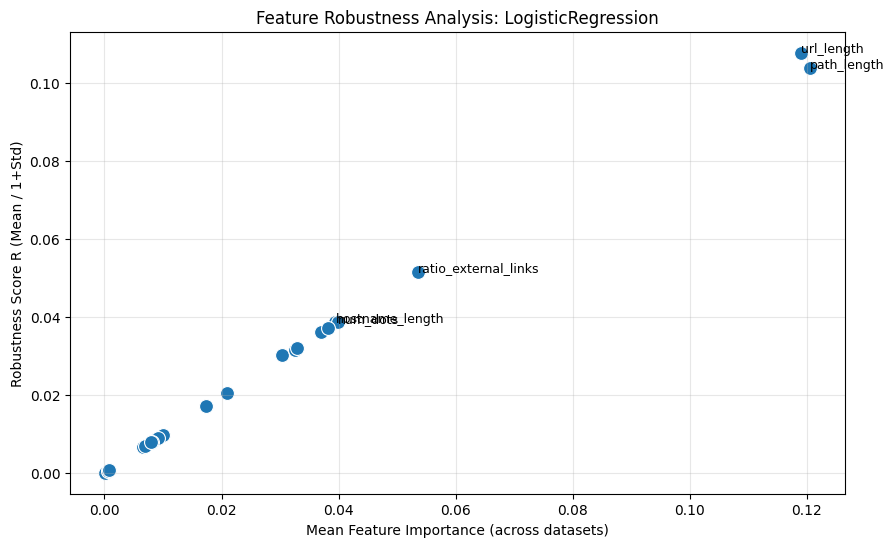

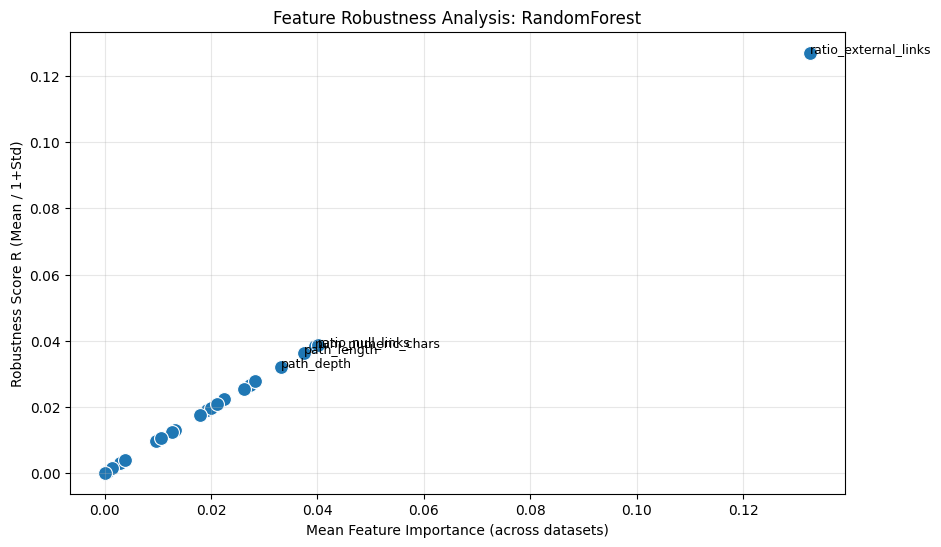

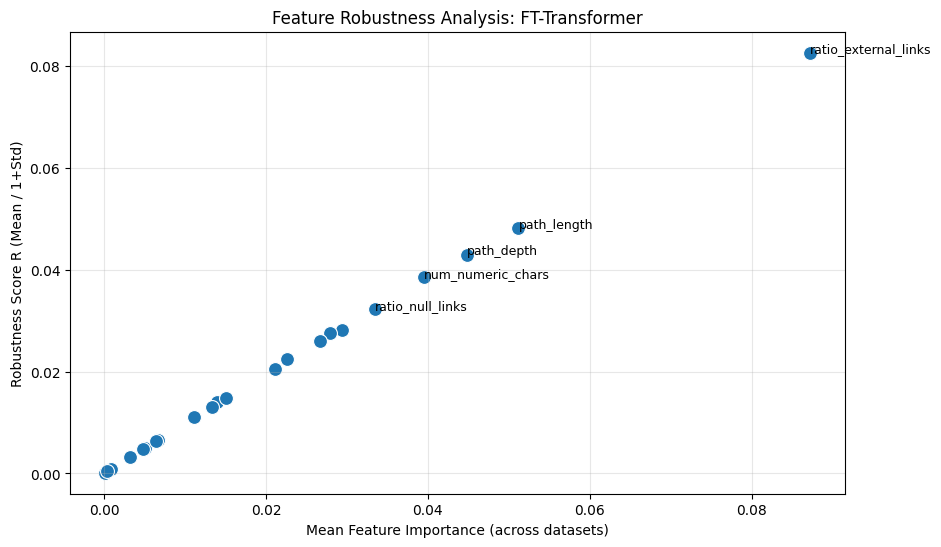

In [14]:
for model_name, df_imp in all_model_importances.items():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_imp, x='Mean_Imp', y='Robustness_R', s=100)

    # Annotate top features
    top_features = df_imp.sort_values('Robustness_R', ascending=False).head(5)
    for idx, row in top_features.iterrows():
        plt.text(row['Mean_Imp'], row['Robustness_R'], idx, fontsize=9, ha='left')

    plt.title(f'Feature Robustness Analysis: {model_name}')
    plt.xlabel('Mean Feature Importance (across datasets)')
    plt.ylabel('Robustness Score R (Mean / 1+Std)')
    plt.grid(True, alpha=0.3)
    plt.show()

Backup output

In [17]:
from google.colab import drive
import shutil
import os
import datetime

# 1. Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define Source and Destination
source_path = './wandb'
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# Saves to a folder named 'wandb_experiments' in your Drive root
destination_path = f'/content/drive/MyDrive/wandb_experiments/wandb_{timestamp}'

# 3. Copy the folder
if os.path.exists(source_path):
    print(f"\nCopying '{source_path}' to '{destination_path}'...\nThis may take a while depending on the size of the logs.")
    try:
        shutil.copytree(source_path, destination_path)
        print(f"✅ Successfully saved wandb folder to: {destination_path}")
    except Exception as e:
        print(f"❌ Error copying folder: {e}")
else:
    print(f"⚠️ Source folder '{source_path}' does not exist. Ensure wandb logging was active.")

Mounting Google Drive...
Mounted at /content/drive

Copying './wandb' to '/content/drive/MyDrive/wandb_experiments/wandb_2025-11-29_06-14-44'...
This may take a while depending on the size of the logs.
✅ Successfully saved wandb folder to: /content/drive/MyDrive/wandb_experiments/wandb_2025-11-29_06-14-44


In [ ]:
from google.colab import runtime
import time

print("Finalizing experiments and disconnecting...")
time.sleep(10)
runtime.unassign()
print("✓ GPU session ended - billing stopped")